In [ ]:
%%capture
!pip install transformers datasets soundfile scikit-learn matplotlib umap-learn
!pip install torch numpy

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-xls-r-300m and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Processing language: Icelandic
Processed sample with ID 1 for Icelandic. Transcription: á mánudag tilkynntu vísindamenn frá læknadeild stanford-háskóla uppfinningu á nýju greiningartæki sem getur flokkað frumur eftir tegund örlítill prentanleg flaga sem hægt er að framleiða með venjulegum bleksprautuprentara fyrir mögulega um eitt bandarískt sent stykkið
Processed sample with ID 2 for Icelandic. Transcription: leiðandi vísindamenn segja að þetta geti orðið til snemmbúinnar greiningar á krabbameini berklum alnæmi og malaríu hjá sjúklingum í lágtekjulöndum þar sem lifunarhlutfall fyrir sjúkdóma á borð við brjóstakrabbamein getur verið helmingi lægri en hjá ríkari löndum
Processed sample with ID 3 for Icelandic. Transcription: jas 39c gripen-flugvélin brotlenti á flugbraut um klukkan 9:30 að staðartíma 02:30 utc. hún sprakk og lokað var á allt áætlunarflug á flugvellinum
Processed sample with ID 6 for Icelandic. Transcription: hinn 28 ára gamli vidal gekk til liðs við barcelona frá sevil

/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


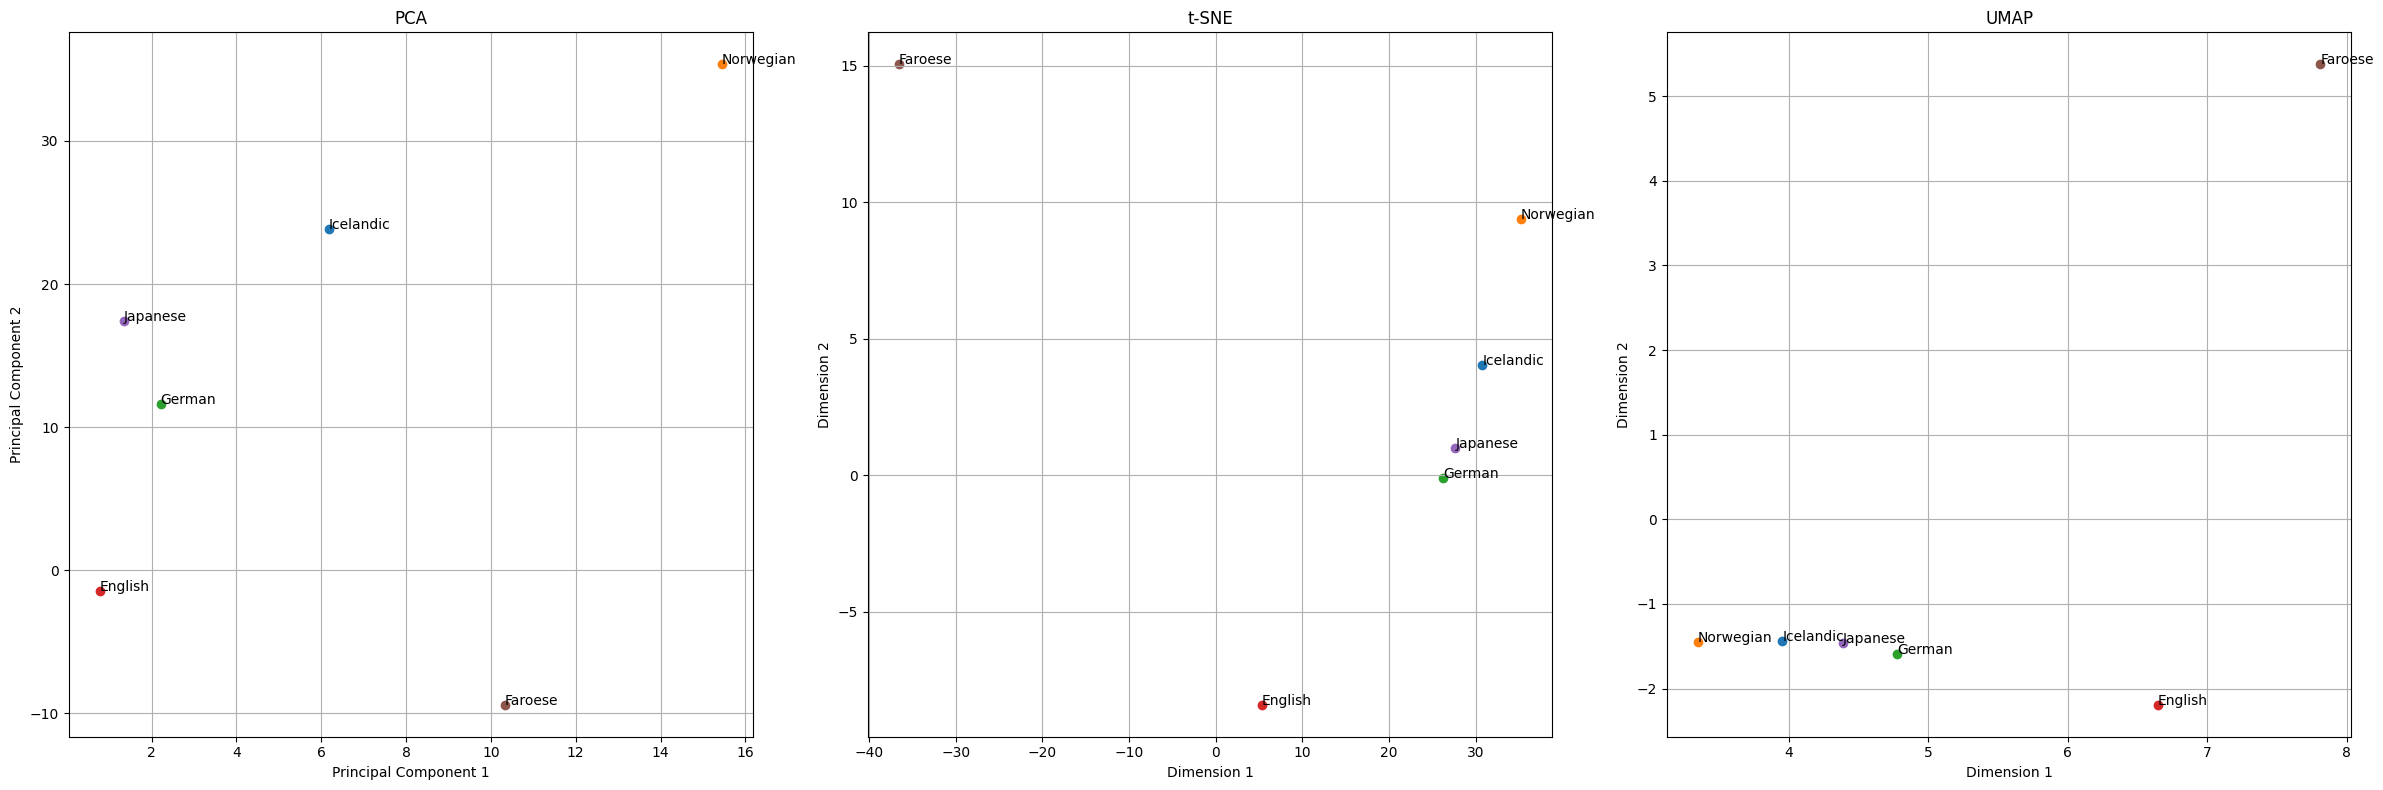

In [ ]:
import torch
import numpy as np
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Model
from datasets import load_dataset, get_dataset_config_names, load_from_disk
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.pyplot as plt
from datetime import datetime
import os

# Define the languages and their language codes
languages = {
    'Icelandic': 'is_is',
    'Norwegian': 'nb_no',
    'Danish': 'da_dk',
    'Swedish': 'sv_se',
    'German': 'de_de',
    'English': 'en_us',
    'Spanish': 'es_419', # es_es
    'French': 'fr_fr',
    'Italian': 'it_it',
    'Hindi': 'hi_in',
    'Vietnamese': 'vi_vn',
    'Japanese': 'ja_jp',
    # add more langauges here
    'Faroese': None
}


#########################################################################################
### SETTINGS

# Specify the number of sentences you want to select
n = 900

embeddings_all = True

model_name = "facebook/wav2vec2-large-xlsr-53"

google_drive_path_fleurs = '/content/drive/MyDrive/Phd/datasets/asr/google_fleurs/'
google_drive_path_ravnursson = '/content/drive/MyDrive/Phd/datasets/asr/ravnursson_asr'

#########################################################################################


# Define a function to generate an array of integers from 1 to n
def generate_integer_array(n):
    return list(range(1, n + 1))

# Generate the sentence IDs
sentence_ids = generate_integer_array(n)

# Load the wav2vec2 multilingual pretrained model and feature extractor
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(
    model_name,
    trust_remote_code=True
)
model = Wav2Vec2Model.from_pretrained(
    model_name,
    output_hidden_states=True,
    trust_remote_code=True
)

all_hidden_states = any
# Run the model in evaluation mode
model.eval()

# Get and embeddings for speech from the model
def extract_embedding(speech_array, sampling_rate):
    # Preprocess the audio
    inputs = feature_extractor(
        speech_array, sampling_rate=sampling_rate, return_tensors="pt", padding=True
    )
    # Get the model's last hidden states
    with torch.no_grad():
        outputs = model(**inputs)
        hidden_states_local = outputs.last_hidden_state # investigate earlier hidden states
        hidden_states_all = outputs.hidden_states
    # You can similarly extract embeddings from all layers
    all_hidden_states = [layer.squeeze(0).cpu().numpy() for layer in hidden_states_all]  # List of NumPy arrays for each layer
    # Compute the mean of the hidden states to get a fixed-size embedding
    embedding = torch.mean(hidden_states_local, dim=1).squeeze().numpy()
    return embedding

embeddings = []
labels = []

# Loop over each language and process the selected sentences
for language_name, language_code in languages.items():
    print(f"\nProcessing language: {language_name}")
    try:
        if language_name != 'Faroese':
            # Load the dataset for the given language
            # dataset = load_dataset('google/fleurs', language_code, split='train', trust_remote_code=True) # load from Hugging Face
            dataset = load_from_disk(os.path.join(google_drive_path_fleurs, language_code)) # load from Google Drive
            # Filter the dataset to only include the sentences with the specified IDs
            dataset_filtered = dataset.filter(lambda example: example['id'] in sentence_ids)
            # Sort the filtered dataset by 'id' in ascending order
            dataset_filtered = dataset_filtered.sort('id')
            # Remove duplicates based on 'id'
            seen_ids = set()
            def filter_unique_ids(example):
                if example['id'] in seen_ids:
                    return False
                else:
                    seen_ids.add(example['id'])
                    return True
            dataset_filtered = dataset_filtered.filter(filter_unique_ids)
            # Check if dataset_filtered is empty
            if len(dataset_filtered) == 0:
                print(f"No data found for {language_name}. Skipping.")
                continue
            # Process each sample
            language_embeddings = []
            total_samples = len(dataset_filtered)
            for idx, sample in enumerate(dataset_filtered):
                audio = sample['audio']
                speech_array = audio['array']
                sampling_rate = audio['sampling_rate']
                # Extract the embedding
                embedding = extract_embedding(speech_array, sampling_rate)
                if embeddings_all:
                    embeddings.append(embedding)
                else:
                    # Collect embeddings for the language
                    language_embeddings.append(embedding)
                # Only print when idx is smaller than 4 or larger than total_samples - 4
                if idx < 3 or idx > (total_samples - 4):
                    print(f"Processed sample with ID {sample['id']} for {language_name}. Transcription: {sample['transcription']}")

            if not embeddings_all:
                # Compute the mean embedding per the language
                mean_embedding = np.mean(language_embeddings, axis=0)
                embeddings.append(mean_embedding)
            labels.append(language_name)

        else:
            # Load the relevant ASR dataset
            # dataset = load_dataset('carlosdanielhernandezmena/ravnursson_asr', split='train', trust_remote_code=True) # load from Hugging Face
            dataset = load_from_disk(google_drive_path_ravnursson) # load from Google Drive

            # Limit to 'n' samples
            dataset = dataset.select(range(n))
            # Process each sample
            language_embeddings = []
            total_samples = len(dataset)
            for idx, sample in enumerate(dataset):
                audio = sample['audio']
                speech_array = audio['array']
                sampling_rate = audio['sampling_rate']
                # Extract the embedding
                embedding = extract_embedding(speech_array, sampling_rate)
                if embeddings_all:
                    embeddings.append(embedding)
                else:
                    # Collect embeddings for the language
                    language_embeddings.append(embedding)
                # Only print when idx is smaller than 4 or larger than total_samples - 4
                if idx < 3 or idx > (total_samples - 4):
                    # Updated print statement as per your request
                    print(f"Processed sample with sample:id {sample['audio_id']} and idx {idx} for {language_name}. Transcription: {sample['normalized_text']}")

            if not embeddings_all:
                # Compute the mean embedding per the language
                mean_embedding = np.mean(language_embeddings, axis=0)
                embeddings.append(mean_embedding)
            labels.append(language_name)
    except Exception as e:
        print(f"An error occurred while processing {language_name}: {e}")
        continue


# Verify that we have embeddings for all languages
print(f"\nLanguages processed: {labels}")
print(f"Number of embeddings: {len(embeddings)}")

# Check if we have at least two embeddings
if len(embeddings) < 2:
    print("Not enough data to perform PCA. Need at least two languages with embeddings.")

# Convert embeddings to numpy array and normalize
X = np.array(embeddings)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##########################################################################################
## Save embeddings and labels to a file on current server and Google Drive

now = datetime.now()
timestamp = now.strftime('%Y%m%d_%H%M%S')

npz_file_name_mean_embeddings = f"{model_name.replace('facebook/', '')}_language_embeddings-{n}_sentences-{len(embeddings)}_languages_{timestamp}.npz"
path_file_name = f"/content/drive/MyDrive/Phd/datasets/wav2vec2_embeddings"

try:
  np.savez(npz_file_name_mean_embeddings, embeddings=X, labels=labels, n_sentences=n)
  print("\nEmbeddings (mean and all) and labels have been saved to .npz file.")
except Exception as e:
    print(f"An error occurred while saving the .npz-file to Colab server. Error: {e}")

try:
  np.savez(f"{path_file_name}/{npz_file_name_mean_embeddings}", embeddings=X, labels=labels, n_sentences=n)
  print(f".npz embedding-file (mean and all) saved to Google Drive.")
except Exception as e:
    print(f"An error occurred while saving the .npz-file to Google Drive. Error: {e}")

#### Load the embeddings and labels like this
# data = np.load('/content/drive/MyDrive/Phd/datasets/asr/wav2vec2_embeddings/<name_of_file>.npz', allow_pickle=True)
# embeddings = data['embeddings']
# labels = data['labels'].tolist()
##########################################################################################


# Dimensionality reduction using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Dimensionality reduction using t-SNE
tsne = TSNE(n_components=2, perplexity=5, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Dimensionality reduction using UMAP
umap_reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_reducer.fit_transform(X_scaled)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# PCA Plot
axes[0].set_title('PCA')
for i, language_name in enumerate(labels):
    axes[0].scatter(X_pca[i, 0], X_pca[i, 1])
    axes[0].annotate(language_name, (X_pca[i, 0], X_pca[i, 1]))
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].grid(True)
# Removed legend

# t-SNE Plot
axes[1].set_title('t-SNE')
for i, language_name in enumerate(labels):
    axes[1].scatter(X_tsne[i, 0], X_tsne[i, 1])
    axes[1].annotate(language_name, (X_tsne[i, 0], X_tsne[i, 1]))
axes[1].set_xlabel('Dimension 1')
axes[1].set_ylabel('Dimension 2')
axes[1].grid(True)
# Removed legend

# UMAP Plot
axes[2].set_title('UMAP')
for i, language_name in enumerate(labels):
    axes[2].scatter(X_umap[i, 0], X_umap[i, 1])
    axes[2].annotate(language_name, (X_umap[i, 0], X_umap[i, 1]))
axes[2].set_xlabel('Dimension 1')
axes[2].set_ylabel('Dimension 2')
axes[2].grid(True)
# Removed legend

plt.tight_layout()
plt.show()